# 11 — Tableaux et figures du manuscrit (hors augmentation)

Ce notebook régénère, à partir des sorties déjà produites par les notebooks 07/08/10
(pipeline sans fuite, dataset `radio_features_clean_ref.csv`, 327 mesures) et de calculs
complémentaires légers, l'ensemble des tableaux et figures **calculables** de l'article
IEEE Access, à l'exception de la section IV-D / VI-C (augmentation de données).

Toutes les sorties (CSV, LaTeX, PNG) sont produites **en anglais**, prêtes pour le manuscrit.
Les chiffres reflètent le pipeline *actuel* (327 mesures, importance par permutation
out-of-fold dans Dev) et non les valeurs imprimées dans le brouillon PDF — voir la note
de méthode en tête du notebook 07.

| Item article | Source | Statut |
|---|---|---|
| Table 2 — operating conditions | nouveau calcul | généré ici |
| Table 3 — predictor taxonomy | statique | généré ici |
| Table 4 — hyperparameter search space | statique (miroir du code nb07) | généré ici |
| Table 5 — three importance lenses | nouveau calcul | généré ici |
| Figure 4 — Borda rank | `outputs_nb07/fig_borda_rank_dev.png` | copié ici |
| Table 6 — best Pure ML per model | `outputs_nb07/final_test_results.csv` | reformaté |
| Figure 5 — core-set ablation | `outputs_nb07/fig_core_set_ablation_dev.png` | copié ici |
| Figure 6 — progressive Hata calibration | `outputs_nb08/cross_family_final.csv` | nouveau graphique |
| Table 7 — Pure ML / A1 / A2 per model | `outputs_nb08/cross_family_final.csv` | pivot |
| Table 8 — cross-family + bootstrap CI | `outputs_nb10/resultats_avec_IC.csv` | filtré/formaté |
| Table 9 — augmentation | — | **exclu**, hors périmètre |
| Figures 1–3 — schémas de méthode | — | non calculables (illustrations) |


---
## §0 — Imports & configuration

In [2]:
import warnings
warnings.filterwarnings('ignore')

import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.inspection import permutation_importance

BASE = Path('.').resolve()
OUT  = BASE / 'outputs_nb11'
OUT.mkdir(exist_ok=True)

NB07 = BASE / 'outputs_nb07'
NB08 = BASE / 'outputs_nb08'
NB10 = BASE / 'outputs_nb10'

SEED   = 42
TARGET = 'E_field'
np.random.seed(SEED)

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})

def fmt_cols(df_, cols, decimals):
    '''Format numeric columns as fixed-decimal strings so trailing zeros survive
    display (4.830 stays "4.830", not "4.83") — keeps decimal places consistent
    across a whole table instead of depending on Python's default float repr.'''
    df_ = df_.copy()
    for c in cols:
        df_[c] = df_[c].map(lambda x: f'{x:.{decimals}f}')
    return df_

def save_table(df_, name, index=False, float_format='%.3f'):
    '''Save a table both as CSV and as a booktabs LaTeX table.'''
    df_.to_csv(OUT / f'{name}.csv', index=index)
    with open(OUT / f'{name}.tex', 'w', encoding='utf-8') as f:
        f.write(df_.to_latex(index=index, float_format=float_format, escape=True))
    print(f'Saved {name}.csv / {name}.tex  ({df_.shape[0]} rows x {df_.shape[1]} cols)')

def render_table_png(df_, name, title, col_widths=None, bold_top3_cols=None, figsize=None):
    '''Render a dataframe as a simple PNG table image (manuscript-ready figure).'''
    bold_top3_cols = bold_top3_cols or []
    n_rows, n_cols = df_.shape
    if figsize is None:
        figsize = (max(6, 1.35 * n_cols), 0.42 * (n_rows + 2))
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis('off')
    cell_text = df_.astype(str).values
    tbl = ax.table(cellText=cell_text, colLabels=df_.columns, loc='center', cellLoc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.35)
    for (r, c), cell in tbl.get_celld().items():
        if r == 0:
            cell.set_text_props(fontweight='bold')
            cell.set_facecolor('#E8ECF1')
    for col in bold_top3_cols:
        j = list(df_.columns).index(col)
        vals = pd.to_numeric(df_[col], errors='coerce')
        top3_idx = vals.nlargest(3).index
        for ridx in top3_idx:
            r = df_.index.get_loc(ridx) + 1
            tbl.get_celld()[(r, j)].set_text_props(fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=14)
    plt.tight_layout()
    plt.savefig(OUT / f'{name}.pdf', bbox_inches='tight')
    plt.savefig(OUT / f'{name}.png', dpi=150, bbox_inches='tight')
    plt.show()

print('Setup OK.')


Setup OK.


---
## §1 — Données

On recharge le dataset nettoyé utilisé par le pipeline sans fuite (327 mesures), et on
rejoint l'identifiant d'émetteur (`Tx_id`) depuis le fichier brut via `Ref`, uniquement
utile au Tableau 2 (le pipeline de modélisation, lui, n'utilise jamais `Tx_id`).

In [3]:
df = pd.read_csv(BASE / 'radio_features_clean_ref.csv')

raw = pd.read_csv(BASE / 'radio_features.csv')
df = df.merge(raw[['Ref', 'Tx_id']], on='Ref', how='left')
df['City'] = df['Ref'].apply(lambda r: r.rsplit('_', 1)[0].capitalize())

ABLATION_GROUPS = {
    'Baseline':  ['Distance', 'Freq', 'Tx_power', 'Tx_height', 'Rx_height'],
    'Terrain':   ['Slope_Tx_Rx_50m', 'Roughness_Tx_Rx_50m'],
    'Geometry':  ['Azimut_Tx_Rx', 'Tilt_Tx_Rx'],
    'Obstacles': ['LOS', 'First_building_m', 'First_tree_m',
                  'Fresnel_buildings', 'Fresnel_trees',
                  'Buildings_near_Rx', 'Trees_near_Rx'],
    'Weather':   ['Temp', 'Rhum'],
    'Context':   ['Environment'],
}
ALL_FEATURES = [f for feats in ABLATION_GROUPS.values() for f in feats]
feat_to_grp  = {f: g for g, feats in ABLATION_GROUPS.items() for f in feats}
assert len(ALL_FEATURES) == 19

print(f'Dataset: {len(df)} measurements x {len(ALL_FEATURES)} predictors')
print(df.groupby('City').size().rename('n'))


Dataset: 327 measurements x 19 predictors
City
Cotonou    211
Kandi      116
Name: n, dtype: int64


---
## §2 — Table 2: operating conditions of the measurement campaign by city

                Parameter               Cotonou        Kandi
              Environment                 Urban     Suburban
    Number of records (N)                   211          116
       Transmitter(s) [N] coto (190), abca (21)   kand (116)
Carrier frequency f (MHz)                   570          538
    Tx antenna height (m)  abca: 150; coto: 100    kand: 100
    Rx antenna height (m)                    10           10
    Tx-Rx distance d (km)          [0.16, 6.50] [2.09, 6.07]
Saved table2_operating_conditions.csv / table2_operating_conditions.tex  (7 rows x 3 cols)


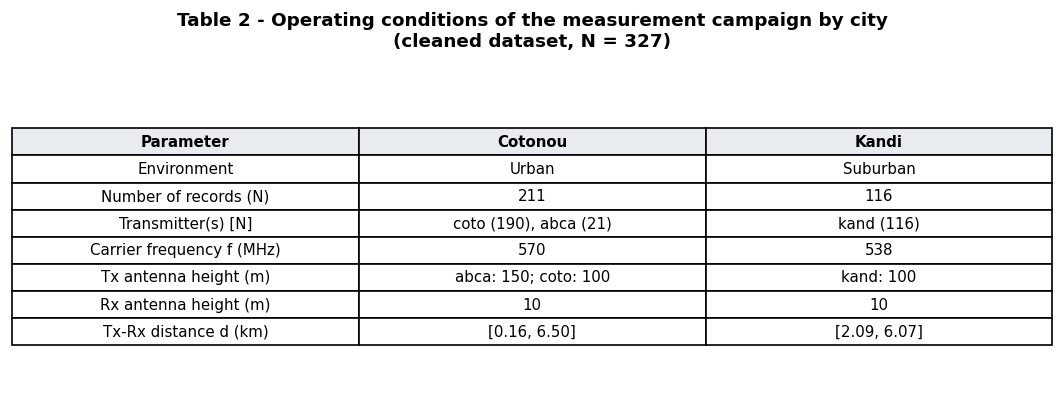

In [4]:
rows = []
for city, g in df.groupby('City'):
    env_lbl = 'Urban' if g['Environment'].iloc[0] == 1 else 'Suburban'
    tx_counts = g['Tx_id'].value_counts()
    tx_str = ', '.join(f'{tid.lower()} ({n})' for tid, n in tx_counts.items())
    freqs = sorted(g['Freq'].unique())
    freq_str = ', '.join(f'{f:.0f}' for f in freqs)
    tx_h = g.groupby('Tx_id')['Tx_antenna_height'].unique()
    tx_h_str = '; '.join(f'{tid.lower()}: {int(v[0])}' for tid, v in tx_h.items())
    rx_h = g['Rx_antenna_height'].unique()
    rx_h_str = ', '.join(f'{int(v)}' for v in rx_h)
    d_km = g['Distance'] / 1000.0
    rows.append({
        'Parameter': 'value',
        'City': city,
        'Environment': env_lbl,
        'Number of records (N)': len(g),
        'Transmitter(s) [N]': tx_str,
        'Carrier frequency f (MHz)': freq_str,
        'Tx antenna height (m)': tx_h_str,
        'Rx antenna height (m)': rx_h_str,
        'Tx-Rx distance d (km)': f'[{d_km.min():.2f}, {d_km.max():.2f}]',
    })

table2 = pd.DataFrame(rows).drop(columns='Parameter').set_index('City').T
table2.index.name = 'Parameter'
table2 = table2.reset_index()
print(table2.to_string(index=False))
save_table(table2, 'table2_operating_conditions')
render_table_png(table2, 'table2_operating_conditions',
                  'Table 2 - Operating conditions of the measurement campaign by city\n'
                  f'(cleaned dataset, N = {len(df)})',
                  figsize=(9, 3.6))


---
## §3 — Table 3: taxonomy of the twenty-two predictors

Saved table3_predictor_taxonomy.csv / table3_predictor_taxonomy.tex  (19 rows x 4 cols)


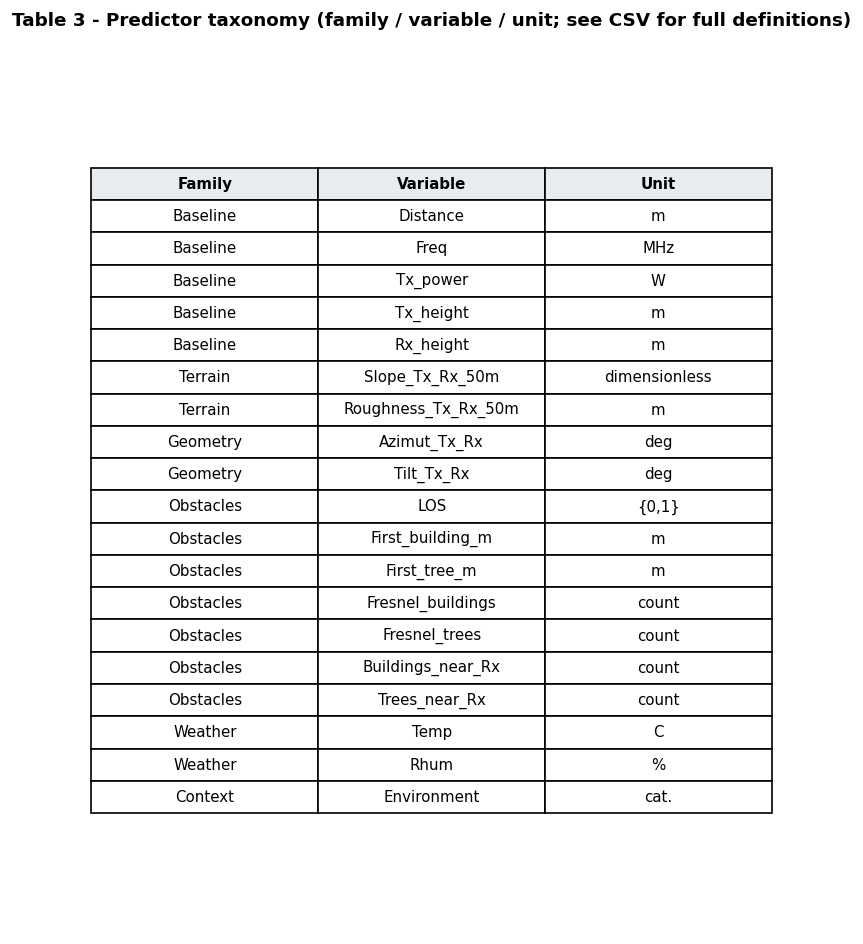

,Family,Variable,Unit,Definition
0,Baseline,Distance,m,Distance between transmission and reception (H...
1,Baseline,Freq,MHz,Carrier frequency of the transmitted signal.
2,Baseline,Tx_power,W,Effective isotropic radiated power at the tran...
3,Baseline,Tx_height,m,Height of the transmitter antenna above ground...
4,Baseline,Rx_height,m,Height of the receiver antenna above ground le...
5,Terrain,Slope_Tx_Rx_50m,dimensionless,Average slope between the transmission point a...
6,Terrain,Roughness_Tx_Rx_50m,m,Rugosity (standard deviation of elevations) be...
7,Geometry,Azimut_Tx_Rx,deg,Horizontal angle between true north and the Tx...
8,Geometry,Tilt_Tx_Rx,deg,Elevation angle of the Tx-Rx line of sight. Po...
9,Obstacles,LOS,"{0,1}",Binary indicator of line-of-sight between Tx a...


In [5]:
TABLE3_DEFS = [
    ('Baseline', 'Distance', 'm', 'Distance between transmission and reception (Haversine distance).'),
    ('Baseline', 'Freq', 'MHz', 'Carrier frequency of the transmitted signal.'),
    ('Baseline', 'Tx_power', 'W', 'Effective isotropic radiated power at the transmitter.'),
    ('Baseline', 'Tx_height', 'm', 'Height of the transmitter antenna above ground level.'),
    ('Baseline', 'Rx_height', 'm', 'Height of the receiver antenna above ground level.'),
    ('Terrain', 'Slope_Tx_Rx_50m', 'dimensionless',
     'Average slope between the transmission point and the point 50 m after reception '
     'along the Tx to Rx direction.'),
    ('Terrain', 'Roughness_Tx_Rx_50m', 'm',
     'Rugosity (standard deviation of elevations) between the transmitter and the point '
     '50 m downstream of the receiver along the Tx to Rx direction.'),
    ('Geometry', 'Azimut_Tx_Rx', 'deg',
     'Horizontal angle between true north and the Tx-Rx direction, measured clockwise '
     'in the range [0 deg, 360 deg).'),
    ('Geometry', 'Tilt_Tx_Rx', 'deg',
     'Elevation angle of the Tx-Rx line of sight. Positive: downtilt (receiver below '
     'transmitter); negative: uptilt (receiver above transmitter).'),
    ('Obstacles', 'LOS', '{0,1}', 'Binary indicator of line-of-sight between Tx and Rx.'),
    ('Obstacles', 'First_building_m', 'm', 'Distance from Tx to the nearest building intercepting the Tx-Rx ray.'),
    ('Obstacles', 'First_tree_m', 'm', 'Distance from Tx to the nearest tree intercepting the Tx-Rx ray.'),
    ('Obstacles', 'Fresnel_buildings', 'count', 'Number of buildings whose footprint intersects the first Fresnel ellipsoid of the Tx-Rx link.'),
    ('Obstacles', 'Fresnel_trees', 'count', 'Number of trees whose canopy intersects the first Fresnel ellipsoid of the Tx-Rx link.'),
    ('Obstacles', 'Buildings_near_Rx', 'count', 'Number of buildings within a fixed radius (50 m) around the receiver.'),
    ('Obstacles', 'Trees_near_Rx', 'count', 'Number of trees within a fixed radius (50 m) around the receiver.'),
    ('Weather', 'Temp', 'C',
     'Ambient air temperature at the measurement time. Retained (with Rhum) for its '
     'established link to atmospheric refractivity; Wdir/Wspd/Pres were dropped as they '
     'have no established physical role in point-to-area median-field prediction.'),
    ('Weather', 'Rhum', '%', 'Relative humidity at the measurement time; drives the wet term of atmospheric refractivity together with Temp.'),
    ('Context', 'Environment', 'cat.', 'Categorical morphology label: urban Cotonou vs. suburban Kandi.'),
]
table3 = pd.DataFrame(TABLE3_DEFS, columns=['Family', 'Variable', 'Unit', 'Definition'])
assert len(table3) == 19 and set(table3['Variable']) == set(ALL_FEATURES)
save_table(table3, 'table3_predictor_taxonomy')
render_table_png(table3.drop(columns='Definition'), 'table3_predictor_taxonomy_short',
                  'Table 3 - Predictor taxonomy (family / variable / unit; see CSV for full definitions)',
                  figsize=(6, 8))
table3


---
## §4 — Table 4: hyperparameter search spaces (Optuna TPE)

Reproduit tel quel depuis les espaces de recherche définis dans le notebook 07
(`_build`/`07_leakfree_pipeline.ipynb`, cellules Optuna) — pas une transcription du PDF.

Saved table4_hyperparameter_search_space.csv / table4_hyperparameter_search_space.tex  (30 rows x 5 cols)


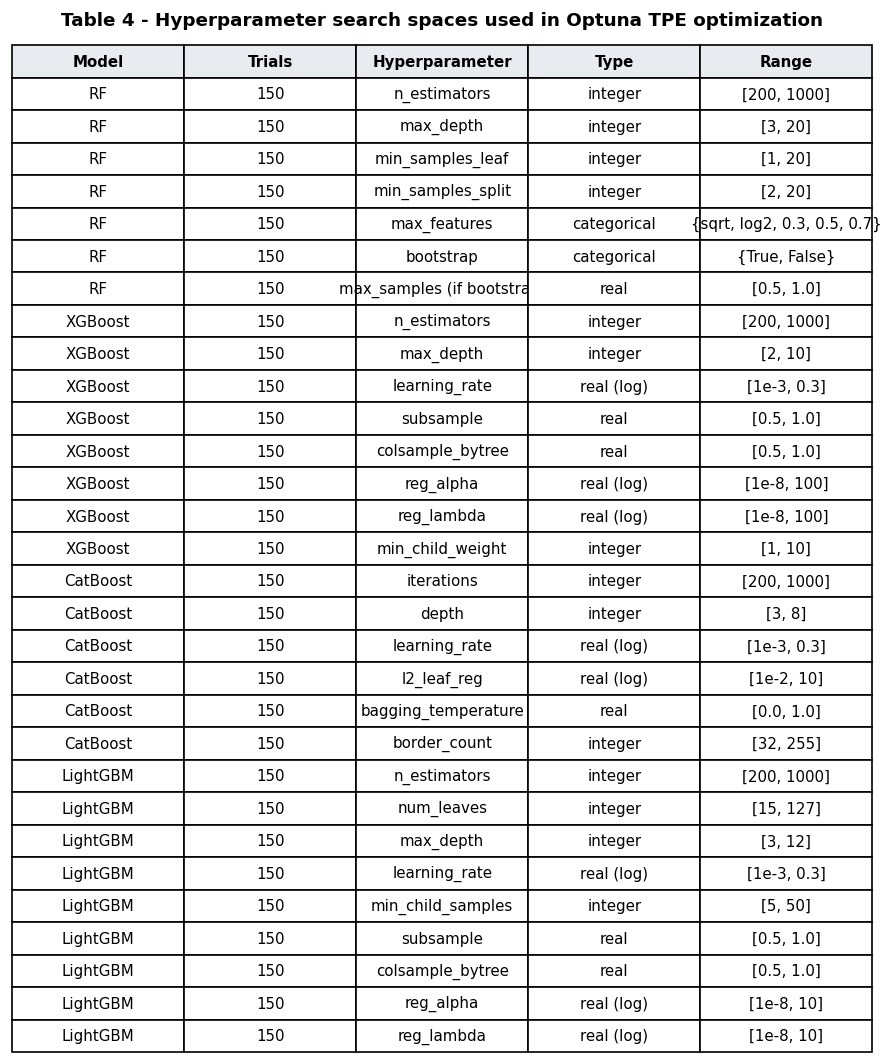

,Model,Trials,Hyperparameter,Type,Range
0,RF,150,n_estimators,integer,"[200, 1000]"
1,RF,150,max_depth,integer,"[3, 20]"
2,RF,150,min_samples_leaf,integer,"[1, 20]"
3,RF,150,min_samples_split,integer,"[2, 20]"
4,RF,150,max_features,categorical,"{sqrt, log2, 0.3, 0.5, 0.7}"
5,RF,150,bootstrap,categorical,"{True, False}"
6,RF,150,max_samples (if bootstrap),real,"[0.5, 1.0]"
7,XGBoost,150,n_estimators,integer,"[200, 1000]"
8,XGBoost,150,max_depth,integer,"[2, 10]"
9,XGBoost,150,learning_rate,real (log),"[1e-3, 0.3]"


In [6]:
N_TRIALS = {'RF': 150, 'XGBoost': 150, 'CatBoost': 150, 'LightGBM': 150}

TABLE4_ROWS = [
    ('RF', 'n_estimators', 'integer', '[200, 1000]'),
    ('RF', 'max_depth', 'integer', '[3, 20]'),
    ('RF', 'min_samples_leaf', 'integer', '[1, 20]'),
    ('RF', 'min_samples_split', 'integer', '[2, 20]'),
    ('RF', 'max_features', 'categorical', '{sqrt, log2, 0.3, 0.5, 0.7}'),
    ('RF', 'bootstrap', 'categorical', '{True, False}'),
    ('RF', 'max_samples (if bootstrap)', 'real', '[0.5, 1.0]'),
    ('XGBoost', 'n_estimators', 'integer', '[200, 1000]'),
    ('XGBoost', 'max_depth', 'integer', '[2, 10]'),
    ('XGBoost', 'learning_rate', 'real (log)', '[1e-3, 0.3]'),
    ('XGBoost', 'subsample', 'real', '[0.5, 1.0]'),
    ('XGBoost', 'colsample_bytree', 'real', '[0.5, 1.0]'),
    ('XGBoost', 'reg_alpha', 'real (log)', '[1e-8, 100]'),
    ('XGBoost', 'reg_lambda', 'real (log)', '[1e-8, 100]'),
    ('XGBoost', 'min_child_weight', 'integer', '[1, 10]'),
    ('CatBoost', 'iterations', 'integer', '[200, 1000]'),
    ('CatBoost', 'depth', 'integer', '[3, 8]'),
    ('CatBoost', 'learning_rate', 'real (log)', '[1e-3, 0.3]'),
    ('CatBoost', 'l2_leaf_reg', 'real (log)', '[1e-2, 10]'),
    ('CatBoost', 'bagging_temperature', 'real', '[0.0, 1.0]'),
    ('CatBoost', 'border_count', 'integer', '[32, 255]'),
    ('LightGBM', 'n_estimators', 'integer', '[200, 1000]'),
    ('LightGBM', 'num_leaves', 'integer', '[15, 127]'),
    ('LightGBM', 'max_depth', 'integer', '[3, 12]'),
    ('LightGBM', 'learning_rate', 'real (log)', '[1e-3, 0.3]'),
    ('LightGBM', 'min_child_samples', 'integer', '[5, 50]'),
    ('LightGBM', 'subsample', 'real', '[0.5, 1.0]'),
    ('LightGBM', 'colsample_bytree', 'real', '[0.5, 1.0]'),
    ('LightGBM', 'reg_alpha', 'real (log)', '[1e-8, 10]'),
    ('LightGBM', 'reg_lambda', 'real (log)', '[1e-8, 10]'),
]
table4 = pd.DataFrame(TABLE4_ROWS, columns=['Model', 'Hyperparameter', 'Type', 'Range'])
table4.insert(1, 'Trials', table4['Model'].map(N_TRIALS))
save_table(table4, 'table4_hyperparameter_search_space')
render_table_png(table4, 'table4_hyperparameter_search_space',
                  'Table 4 - Hyperparameter search spaces used in Optuna TPE optimization',
                  figsize=(7.5, 9))
table4


---
## §5 — Table 5: three complementary importance lenses (Spearman, mutual information,
single-model RF permutation importance on the held-out test set)

Spearman et l'information mutuelle sont calculés sur le dataset complet (327 mesures) ;
la permutation importance utilise le split Dev/Test 80/20 stratifié (`seed=42`, identique
au notebook 07) et les hyperparamètres RF déjà optimisés (`outputs_nb07/best_params_dev.json`).
Cette table est purement descriptive : elle n'entre dans aucune décision de sélection de
features (celles-ci reposent sur le consensus de Borda out-of-fold du notebook 07).

Dev: 261 | Test: 66
Saved table5_three_importance_lenses.csv / table5_three_importance_lenses.tex  (19 rows x 5 cols)


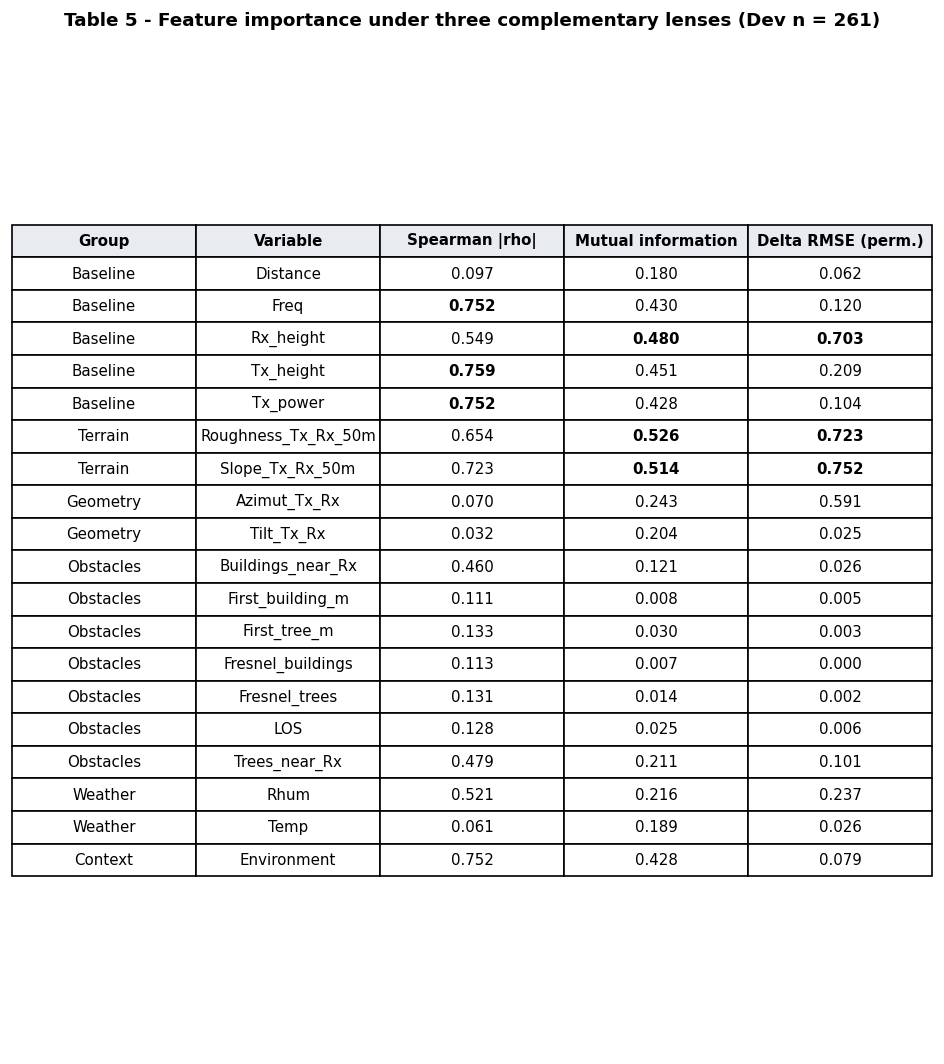

,Group,Variable,Spearman |rho|,Mutual information,Delta RMSE (perm.)
0,Baseline,Distance,0.097,0.180,0.062
1,Baseline,Freq,0.752,0.430,0.120
2,Baseline,Rx_height,0.549,0.480,0.703
3,Baseline,Tx_height,0.759,0.451,0.209
4,Baseline,Tx_power,0.752,0.428,0.104
5,Terrain,Roughness_Tx_Rx_50m,0.654,0.526,0.723
6,Terrain,Slope_Tx_Rx_50m,0.723,0.514,0.752
7,Geometry,Azimut_Tx_Rx,0.070,0.243,0.591
8,Geometry,Tilt_Tx_Rx,0.032,0.204,0.025
9,Obstacles,Buildings_near_Rx,0.460,0.121,0.026


In [13]:
dev_df, test_df = train_test_split(
    df, test_size=0.20, random_state=SEED, stratify=df['Environment']
)
dev_df, test_df = dev_df.reset_index(drop=True), test_df.reset_index(drop=True)
print(f'Dev: {len(dev_df)} | Test: {len(test_df)}')

with open(NB07 / 'best_params_dev.json') as f:
    best_params = json.load(f)

# Lentilles 1 et 2 — sur Dev, exactement comme nb07 (mêmes données, même graine)
X_dev_imp = dev_df[ALL_FEATURES].values
y_dev_imp = dev_df[TARGET].values
spearman_rho = [abs(stats.spearmanr(X_dev_imp[:, i], y_dev_imp)[0])
                for i in range(len(ALL_FEATURES))]
mut_info     = mutual_info_regression(X_dev_imp, y_dev_imp, random_state=SEED)

# Lentille 3 — on ne recalcule rien : on lit la colonne RF de nb07,
# celle-là même qui alimente le classement de Borda.
imp07 = pd.read_csv(NB07 / 'feature_importance_multi_dev.csv').set_index('Feature')
assert set(imp07.index) == set(ALL_FEATURES), 'features désalignées entre nb07 et nb11'
delta_rmse = imp07.loc[ALL_FEATURES, 'Perm_RF'].values

table5 = pd.DataFrame({
    'Group': [feat_to_grp[f] for f in ALL_FEATURES],
    'Variable': ALL_FEATURES,
    'Spearman |rho|': spearman_rho,
    'Mutual information': mut_info,
    'Delta RMSE (perm.)': delta_rmse,
})
group_order = ['Baseline', 'Terrain', 'Geometry', 'Obstacles', 'Weather', 'Context']
table5['Group'] = pd.Categorical(table5['Group'], categories=group_order, ordered=True)
table5 = table5.sort_values(['Group', 'Variable']).reset_index(drop=True)
bold_cols = ['Spearman |rho|', 'Mutual information', 'Delta RMSE (perm.)']
table5_display = fmt_cols(table5, bold_cols, 3)

save_table(table5_display, 'table5_three_importance_lenses')
render_table_png(table5_display, 'table5_three_importance_lenses',
                  f'Table 5 - Feature importance under three complementary lenses (Dev n = {len(dev_df)})',
                  bold_top3_cols=bold_cols,
                  figsize=(8, 9))
table5_display


---
## §6 — Figure 4 (Borda rank) & Table 6 (best Pure ML per model)

Figure 4 est déjà produite par le notebook 07 (`outputs_nb07/fig_borda_rank_dev.png`) — on
la copie simplement dans `outputs_nb11/` pour un livrable consolidé. Table 6 est reformatée
depuis `outputs_nb07/final_test_results.csv` (évaluation sur le test complet, non filtré
par distance).

Figure 4 copied -> outputs_nb11/figure4_borda_rank.png / .pdf
Saved table6_best_pure_ml.csv / table6_best_pure_ml.tex  (4 rows x 4 cols)


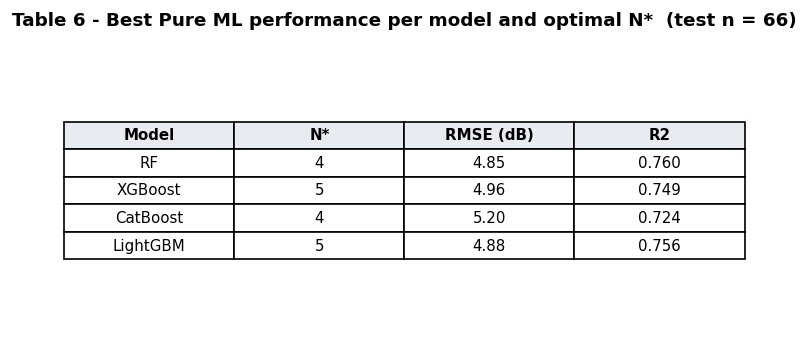

,Model,N*,RMSE (dB),R2
0,RF,4,4.85,0.760
1,XGBoost,5,4.96,0.749
2,CatBoost,4,5.20,0.724
3,LightGBM,5,4.88,0.756


In [8]:
shutil.copy(NB07 / 'fig_borda_rank_dev.png', OUT / 'figure4_borda_rank.png')
shutil.copy(NB07 / 'fig_borda_rank_dev.pdf', OUT / 'figure4_borda_rank.pdf')
print('Figure 4 copied -> outputs_nb11/figure4_borda_rank.png / .pdf')

final_test = pd.read_csv(NB07 / 'final_test_results.csv')
table6 = final_test[final_test['Model'].isin(['RF', 'XGBoost', 'CatBoost', 'LightGBM'])].copy()
table6 = table6[['Model', 'N*', 'RMSE', 'R2']].rename(
    columns={'RMSE': 'RMSE (dB)', 'R2': 'R2'}).reset_index(drop=True)
table6 = fmt_cols(table6, ['RMSE (dB)'], 2)
table6 = fmt_cols(table6, ['R2'], 3)
save_table(table6, 'table6_best_pure_ml')
render_table_png(table6, 'table6_best_pure_ml',
                  f'Table 6 - Best Pure ML performance per model and optimal N*  (test n = {len(test_df)})',
                  figsize=(6, 3))
table6


---
## §7 — Figure 5 (core-set ablation)

Déjà produite par le notebook 07 (`outputs_nb07/fig_core_set_ablation_dev.png`) — copiée
ici pour un livrable consolidé.

In [9]:
shutil.copy(NB07 / 'fig_core_set_ablation_dev.png', OUT / 'figure5_core_set_ablation.png')
shutil.copy(NB07 / 'fig_core_set_ablation_dev.pdf', OUT / 'figure5_core_set_ablation.pdf')
print('Figure 5 copied -> outputs_nb11/figure5_core_set_ablation.png / .pdf')


Figure 5 copied -> outputs_nb11/figure5_core_set_ablation.png / .pdf


---
## §8 — Figure 6: progressive Hata calibration RMSE

Nouveau graphique : les quatre niveaux de calibration Hata sont déjà présents comme des
lignes de `outputs_nb08/cross_family_final.csv` (produit par le notebook 08) ; il ne
manquait que la mise en forme en graphique à barres dédié.

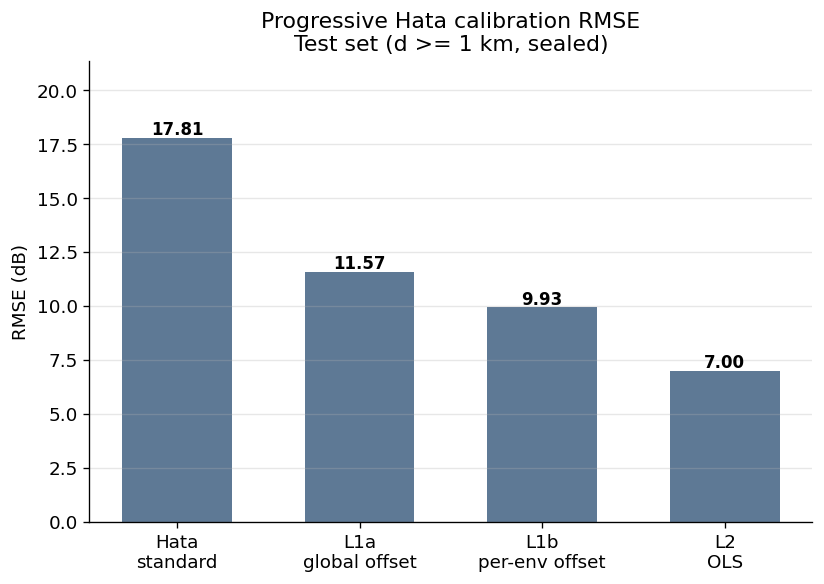

Figure 6 saved.


In [10]:
cff = pd.read_csv(NB08 / 'cross_family_final.csv')
hata_order = ['Hata standard', 'Hata L1a (global offset)', 'Hata L1b (offset/env)', 'Hata L2 (OLS)']
hata_labels = ['Hata\nstandard', 'L1a\nglobal offset', 'L1b\nper-env offset', 'L2\nOLS']
hata = cff.set_index('Modèle').loc[hata_order].reset_index()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(hata_labels, hata['RMSE'], color='#4C6B8A', alpha=0.9, width=0.6)
for b, v in zip(bars, hata['RMSE']):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.15, f'{v:.2f}',
            ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('RMSE (dB)')
ax.set_title('Progressive Hata calibration RMSE\nTest set (d >= 1 km, sealed)')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, hata['RMSE'].max() * 1.2)
plt.tight_layout()
plt.savefig(OUT / 'figure6_hata_calibration.pdf', bbox_inches='tight')
plt.savefig(OUT / 'figure6_hata_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

hata[['Modèle', 'RMSE', 'MAE', 'R2', 'Bias']].rename(columns={'Modèle': 'Model'}).to_csv(
    OUT / 'figure6_hata_calibration_data.csv', index=False)
print('Figure 6 saved.')


---
## §9 — Table 7: Pure ML vs. A1 vs. A2 per model

Pivot de `outputs_nb08/cross_family_final.csv` : pour chaque modèle ML, RMSE et R2 au
meilleur N pour chacun des trois protocoles d'entrainement (Pure ML, hybride A1, hybride A2).
Le paradigme sans hybridation est appelé « Pure ML » (pas « Baseline ») pour éviter toute
confusion avec le groupe de features Baseline (Table 3/5).

Saved table7_pure_ml_a1_a2.csv / table7_pure_ml_a1_a2.tex  (4 rows x 7 cols)


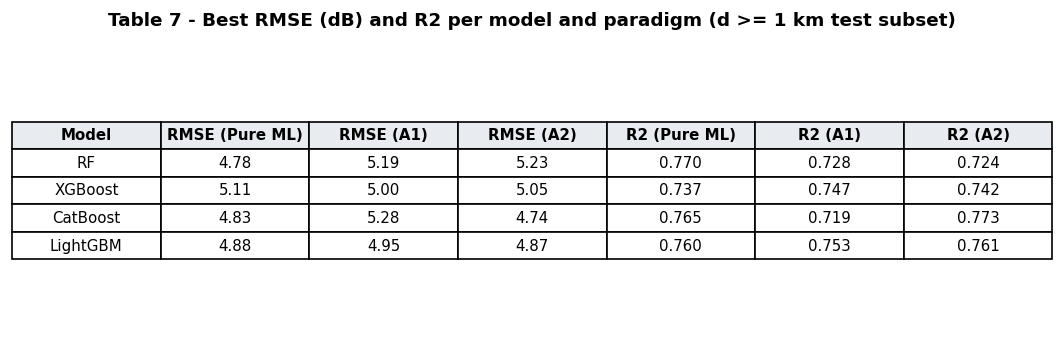

,Model,RMSE (Pure ML),RMSE (A1),RMSE (A2),R2 (Pure ML),R2 (A1),R2 (A2)
0,RF,4.78,5.19,5.23,0.770,0.728,0.724
1,XGBoost,5.11,5.00,5.05,0.737,0.747,0.742
2,CatBoost,4.83,5.28,4.74,0.765,0.719,0.773
3,LightGBM,4.88,4.95,4.87,0.760,0.753,0.761


In [11]:
def base_model(name, prefix):
    return name[len(prefix):] if name.startswith(prefix) else name

rows7 = []
for _, r in cff.iterrows():
    if r['Famille'] == 'Pure ML':
        rows7.append({'Model': r['Modèle'], 'Paradigm': 'Pure ML', 'RMSE': r['RMSE'], 'R2': r['R2']})
    elif r['Famille'] == 'Hybrid A1':
        rows7.append({'Model': base_model(r['Modèle'], 'A1-'), 'Paradigm': 'A1', 'RMSE': r['RMSE'], 'R2': r['R2']})
    elif r['Famille'] == 'Hybrid A2':
        rows7.append({'Model': base_model(r['Modèle'], 'A2-'), 'Paradigm': 'A2', 'RMSE': r['RMSE'], 'R2': r['R2']})

long7 = pd.DataFrame(rows7)
model_order = ['RF', 'XGBoost', 'CatBoost', 'LightGBM']
long7['Model'] = pd.Categorical(long7['Model'], categories=model_order, ordered=True)
rmse7 = long7.pivot(index='Model', columns='Paradigm', values='RMSE')[['Pure ML', 'A1', 'A2']]
r2_7  = long7.pivot(index='Model', columns='Paradigm', values='R2')[['Pure ML', 'A1', 'A2']]

table7 = pd.concat({'RMSE': rmse7, 'R2': r2_7}, axis=1).reset_index()
table7.columns = ['Model'] + [f'{m} ({p})' for m, p in table7.columns[1:]]
table7 = fmt_cols(table7, [c for c in table7.columns if c.startswith('RMSE')], 2)
table7 = fmt_cols(table7, [c for c in table7.columns if c.startswith('R2')], 3)
save_table(table7, 'table7_pure_ml_a1_a2')
render_table_png(table7, 'table7_pure_ml_a1_a2',
                  'Table 7 - Best RMSE (dB) and R2 per model and paradigm (d >= 1 km test subset)',
                  figsize=(9, 3))
table7


---
## §10 — Table 8: cross-family comparison with bootstrap confidence intervals

Filtre de `outputs_nb10/resultats_avec_IC.csv` (2000 rééchantillonnages bootstrap, IC
percentile à 95 %, déjà produit par le notebook 10) vers les cinq lignes représentatives
du Tableau 8 de l'article : les deux baselines empiriques non calibrées, la meilleure
calibration empirique, le meilleur modèle Pure ML, et le meilleur hybride.

Saved table8_cross_family_with_ci.csv / table8_cross_family_with_ci.tex  (5 rows x 6 cols)


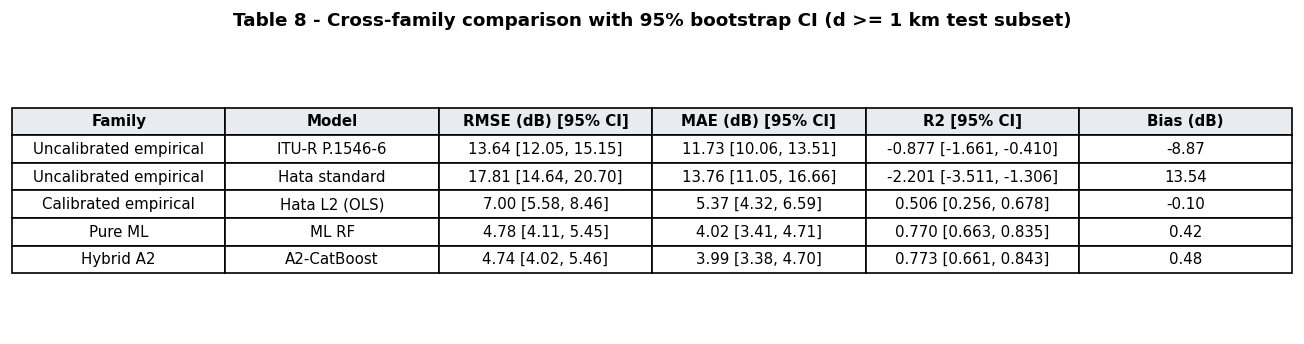

,Family,Model,RMSE (dB) [95% CI],MAE (dB) [95% CI],R2 [95% CI],Bias (dB)
0,Uncalibrated empirical,ITU-R P.1546-6,"13.64 [12.05, 15.15]","11.73 [10.06, 13.51]","-0.877 [-1.661, -0.410]",-8.87
1,Uncalibrated empirical,Hata standard,"17.81 [14.64, 20.70]","13.76 [11.05, 16.66]","-2.201 [-3.511, -1.306]",13.54
2,Calibrated empirical,Hata L2 (OLS),"7.00 [5.58, 8.46]","5.37 [4.32, 6.59]","0.506 [0.256, 0.678]",-0.10
3,Pure ML,ML RF,"4.78 [4.11, 5.45]","4.02 [3.41, 4.71]","0.770 [0.663, 0.835]",0.42
4,Hybrid A2,A2-CatBoost,"4.74 [4.02, 5.46]","3.99 [3.38, 4.70]","0.773 [0.661, 0.843]",0.48


In [12]:
ic = pd.read_csv(NB10 / 'resultats_avec_IC.csv')

def ci_str(v, lo, hi, d=2):
    return f'{v:.{d}f} [{lo:.{d}f}, {hi:.{d}f}]'

uncal = ic[ic['Famille'] == 'Uncalibrated empirical']
best_emp = ic[ic['Famille'] == 'Calibrated empirical'].sort_values('RMSE').iloc[[0]]
# Pure ML is trained on the FULL Dev set (no d>=1km filter) in nb10 — matching Table 6/7 and
# the methodological choice that ML, unlike Hata, has no physical reason to discard d<1km
# points. The filtered-Dev variant was removed from nb10 to avoid this exact ambiguity.
best_ml  = ic[ic['Famille'] == 'Pure ML'].sort_values('RMSE').iloc[[0]]
best_hyb = ic[ic['Famille'].isin(['Hybrid A1', 'Hybrid A2'])].sort_values('RMSE').iloc[[0]]

table8_src = pd.concat([uncal, best_emp, best_ml, best_hyb], ignore_index=True)
table8 = pd.DataFrame({
    'Family': table8_src['Famille'],
    'Model': table8_src['Modèle'],
    'RMSE (dB) [95% CI]': [ci_str(v, lo, hi) for v, lo, hi in
                            zip(table8_src['RMSE'], table8_src['RMSE_lo'], table8_src['RMSE_hi'])],
    'MAE (dB) [95% CI]': [ci_str(v, lo, hi) for v, lo, hi in
                           zip(table8_src['MAE'], table8_src['MAE_lo'], table8_src['MAE_hi'])],
    'R2 [95% CI]': [ci_str(v, lo, hi, 3) for v, lo, hi in
                     zip(table8_src['R2'], table8_src['R2_lo'], table8_src['R2_hi'])],
    'Bias (dB)': table8_src['Bias'].map(lambda x: f'{x:.2f}'),
})
save_table(table8, 'table8_cross_family_with_ci')
render_table_png(table8, 'table8_cross_family_with_ci',
                  'Table 8 - Cross-family comparison with 95% bootstrap CI (d >= 1 km test subset)',
                  figsize=(11, 3))
table8


---
## Résumé

Tous les tableaux (`table*.csv` / `.tex` / `.png`) et figures (`figure*.png` / `.pdf`) sont
dans `outputs_nb11/`. La Table 9 (augmentation) est explicitement hors périmètre de ce
notebook ; les Figures 1 à 3 sont des schémas de méthode non calculables à partir des
données.